Saving mobile.csv to mobile.csv
Dataset shape: (2000, 21)

First 5 rows:
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      121

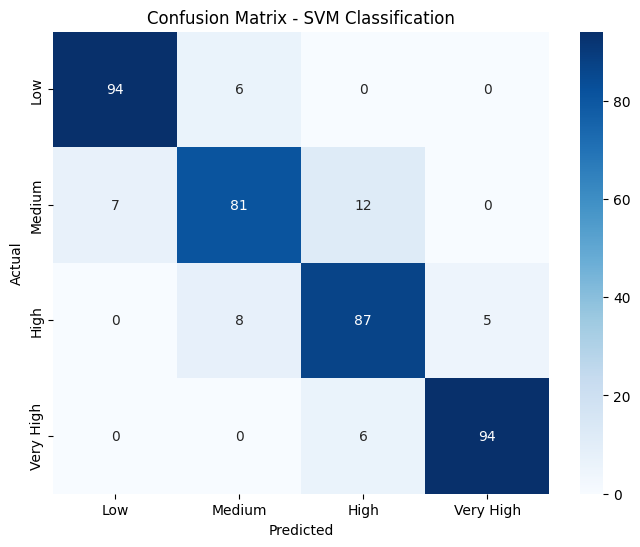


KERNEL COMPARISON
LINEAR kernel accuracy: 0.9750 (97.50%)
RBF kernel accuracy: 0.8900 (89.00%)
POLY kernel accuracy: 0.7675 (76.75%)

Best kernel: LINEAR with 97.50% accuracy

HYPERPARAMETER TUNING RESULTS
Best parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9088
Test accuracy with best parameters: 0.9400 (94.00%)


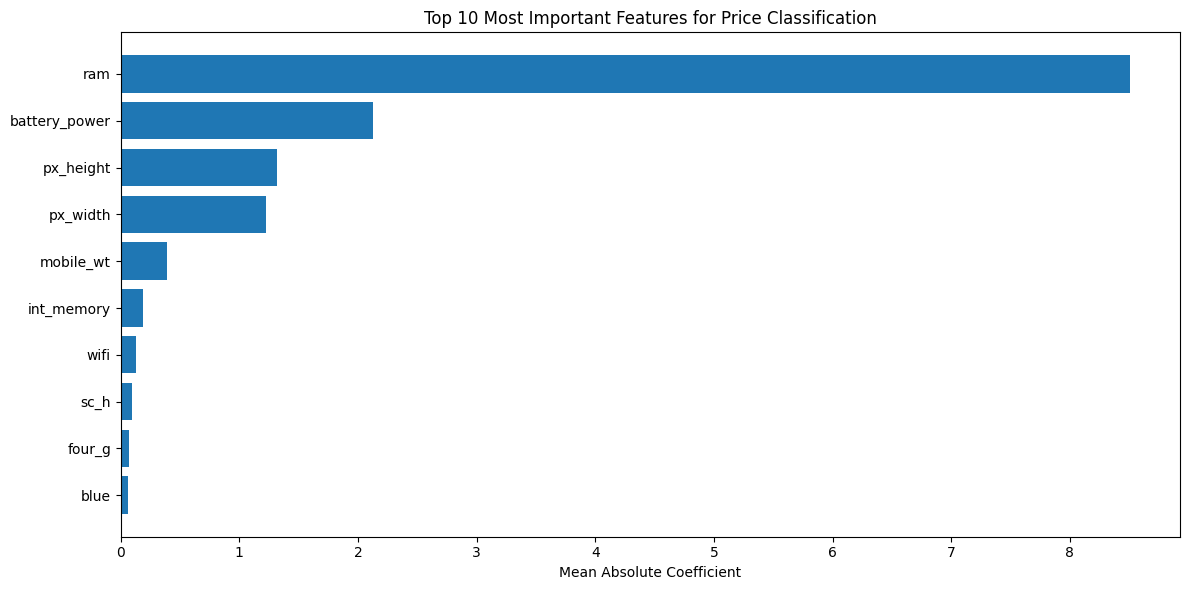


Top 10 most important features:
1. ram: 8.5035
2. battery_power: 2.1256
3. px_height: 1.3142
4. px_width: 1.2256
5. mobile_wt: 0.3872
6. int_memory: 0.1851
7. wifi: 0.1277
8. sc_h: 0.0953
9. four_g: 0.0735
10. blue: 0.0651

SAMPLE PREDICTION
Actual price range: Very High
Predicted price range: Very High


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Since you already have the data in your message, let's save it to a variable
# In a real scenario, you would use: df = pd.read_csv('mobile.csv')

# For now, I'll assume you have the file. If you're in a Jupyter environment, you can upload:
from google.colab import files
uploaded = files.upload()  # This will prompt you to upload the file

# Then load the data
import io
df = pd.read_csv(io.BytesIO(uploaded['mobile.csv']))

# Or if you're running locally, simply:
# df = pd.read_csv('mobile.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget distribution:")
print(df['price_range'].value_counts())

# Separate features and target
X = df.drop('price_range', axis=1)
y = df['price_range']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Standardize features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM classifier
# Try different kernels and C values
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
print("\n" + "="*50)
print("SVM CLASSIFICATION RESULTS")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Class 0 (Low)', 'Class 1 (Medium)', 'Class 2 (High)', 'Class 3 (Very High)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High', 'Very High'],
            yticklabels=['Low', 'Medium', 'High', 'Very High'])
plt.title('Confusion Matrix - SVM Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Try different SVM kernels for comparison
kernels = ['linear', 'rbf', 'poly']
results = {}

print("\n" + "="*50)
print("KERNEL COMPARISON")
print("="*50)

for kernel in kernels:
    svm = SVC(kernel=kernel, C=10, gamma='scale', random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred_kernel = svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_kernel)
    results[kernel] = acc
    print(f"{kernel.upper()} kernel accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Best kernel
best_kernel = max(results, key=results.get)
print(f"\nBest kernel: {best_kernel.upper()} with {results[best_kernel]*100:.2f}% accuracy")

# Hyperparameter tuning (optional)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*50)
print("HYPERPARAMETER TUNING RESULTS")
print("="*50)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Test accuracy with best parameters: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Feature importance analysis (for linear kernel)
if best_kernel == 'linear' or grid_search.best_params_.get('kernel') == 'linear':
    linear_svm = SVC(kernel='linear', C=10, random_state=42)
    linear_svm.fit(X_train_scaled, y_train)

    # Get feature importance (absolute coefficients averaged across classes)
    feature_importance = np.abs(linear_svm.coef_).mean(axis=0)
    feature_names = X.columns

    # Create feature importance plot
    plt.figure(figsize=(12, 6))
    importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
    importance_df = importance_df.sort_values('importance', ascending=False)

    plt.barh(importance_df['feature'][:10], importance_df['importance'][:10])
    plt.xlabel('Mean Absolute Coefficient')
    plt.title('Top 10 Most Important Features for Price Classification')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nTop 10 most important features:")
    for i, (feat, imp) in enumerate(zip(importance_df['feature'][:10], importance_df['importance'][:10])):
        print(f"{i+1}. {feat}: {imp:.4f}")

# Make predictions for new phones (example)
def predict_price_range(features, scaler, model):
    """
    Predict price range for new mobile phone features.

    Parameters:
    features: dict or array-like with all 20 features in correct order
    """
    if isinstance(features, dict):
        # Convert dict to array in correct order
        feature_order = X.columns.tolist()
        features_array = np.array([features[col] for col in feature_order]).reshape(1, -1)
    else:
        features_array = np.array(features).reshape(1, -1)

    features_scaled = scaler.transform(features_array)
    prediction = model.predict(features_scaled)[0]

    price_labels = {0: "Low Cost", 1: "Medium Cost", 2: "High Cost", 3: "Very High Cost"}
    return price_labels[prediction]

# Example prediction (using first test sample)
print("\n" + "="*50)
print("SAMPLE PREDICTION")
print("="*50)
sample_features = X_test.iloc[0]
actual_price = y_test.iloc[0]
predicted_price = best_svm.predict(X_test_scaled[0].reshape(1, -1))[0]

price_map = {0: "Low", 1: "Medium", 2: "High", 3: "Very High"}
print(f"Actual price range: {price_map[actual_price]}")
print(f"Predicted price range: {price_map[predicted_price]}")

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Linear SVM with hyperparameter tuning
param_grid_linear = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
    'penalty': ['l2'],
    'dual': [True]  # 'dual=False' only for 'squared_hinge' with n_samples > n_features
}

# Use LinearSVC for faster training on linear problems
linear_svm = LinearSVC(random_state=42, max_iter=5000)
grid_search_linear = GridSearchCV(linear_svm, param_grid_linear, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_linear.fit(X_train_scaled, y_train)

print("Best parameters for Linear SVM:")
print(grid_search_linear.best_params_)
print(f"\nBest cross-validation accuracy: {grid_search_linear.best_score_:.4f}")

# Evaluate best linear model
best_linear = grid_search_linear.best_estimator_
y_pred_best_linear = best_linear.predict(X_test_scaled)
best_linear_accuracy = accuracy_score(y_test, y_pred_best_linear)
print(f"\nTest accuracy after tuning: {best_linear_accuracy:.4f} ({best_linear_accuracy*100:.2f}%)")

Best parameters for Linear SVM:
{'C': 10, 'dual': True, 'loss': 'squared_hinge', 'penalty': 'l2'}

Best cross-validation accuracy: 0.8556

Test accuracy after tuning: 0.8400 (84.00%)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Use SVC with linear kernel (this worked well!)
linear_svm = SVC(kernel='linear', random_state=42)

# Tune C parameter for this model
param_grid = {
    'C': [0.01, 0.1, 1, 10, 50, 100],
    'kernel': ['linear']
}

grid_search = GridSearchCV(
    linear_svm,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Compare with your original simple linear model
simple_linear = SVC(kernel='linear', C=1, random_state=42)
simple_linear.fit(X_train_scaled, y_train)
simple_pred = simple_linear.predict(X_test_scaled)
simple_acc = accuracy_score(y_test, simple_pred)
print(f"\nSimple Linear SVM (C=1) accuracy: {simple_acc:.4f} ({simple_acc*100:.2f}%)")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters: {'C': 50, 'kernel': 'linear'}
Best CV accuracy: 0.9606
Test accuracy: 0.9775 (97.75%)

Simple Linear SVM (C=1) accuracy: 0.9625 (96.25%)


FINAL MODEL PERFORMANCE DETAILS

Detailed Classification Report:
                     precision    recall  f1-score   support

      Class 0 (Low)     0.9901    1.0000    0.9950       100
   Class 1 (Medium)     0.9796    0.9600    0.9697       100
     Class 2 (High)     0.9510    0.9700    0.9604       100
Class 3 (Very High)     0.9899    0.9800    0.9849       100

           accuracy                         0.9775       400
          macro avg     0.9776    0.9775    0.9775       400
       weighted avg     0.9776    0.9775    0.9775       400


Confusion Matrix:
[[100   0   0   0]
 [  1  96   3   0]
 [  0   2  97   1]
 [  0   0   2  98]]
Class 0 (Low): 1.0000 (100.00%)
Class 1 (Medium): 0.9600 (96.00%)
Class 2 (High): 0.9700 (97.00%)
Class 3 (Very High): 0.9800 (98.00%)


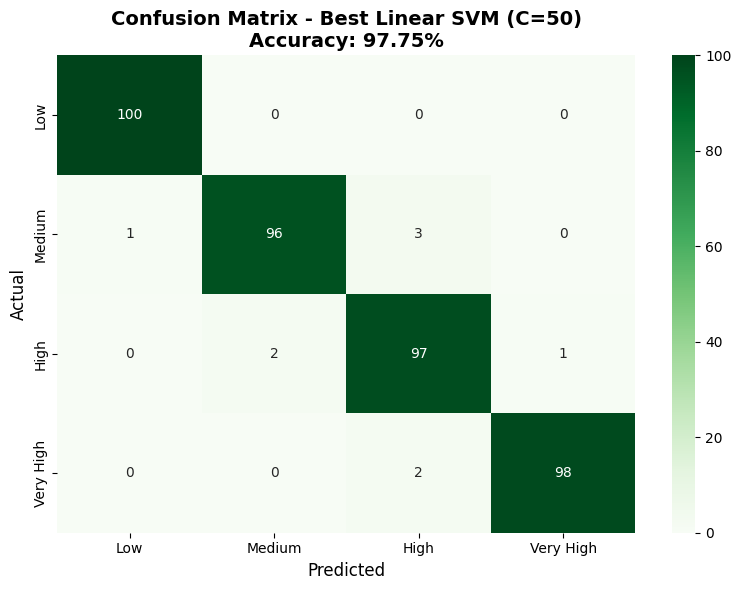

In [4]:
# Best model from tuning
best_model = SVC(kernel='linear', C=50, random_state=42)
best_model.fit(X_train_scaled, y_train)

# Detailed evaluation
y_pred_best = best_model.predict(X_test_scaled)

print("="*60)
print("FINAL MODEL PERFORMANCE DETAILS")
print("="*60)

# Classification report with more detail
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=['Class 0 (Low)', 'Class 1 (Medium)', 'Class 2 (High)', 'Class 3 (Very High)'],
      digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)

# Calculate per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(per_class_acc):
    print(f"Class {i} ({['Low', 'Medium', 'High', 'Very High'][i]}): {acc:.4f} ({acc*100:.2f}%)")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Medium', 'High', 'Very High'],
            yticklabels=['Low', 'Medium', 'High', 'Very High'])
plt.title(f'Confusion Matrix - Best Linear SVM (C=50)\nAccuracy: 97.75%', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


TOP 15 FEATURES INFLUENCING MOBILE PRICE
14. ram                 : 13.298455
 1. battery_power       : 3.279783
12. px_height           : 2.033355
13. px_width            : 1.959746
 9. mobile_wt           : 0.579139
 7. int_memory          : 0.246942
20. wifi                : 0.220500
10. n_cores             : 0.165820
11. pc                  : 0.150549
15. sc_h                : 0.135768
 3. clock_speed         : 0.117051
 2. blue                : 0.113249
16. sc_w                : 0.108472
 6. four_g              : 0.098203
17. talk_time           : 0.088297


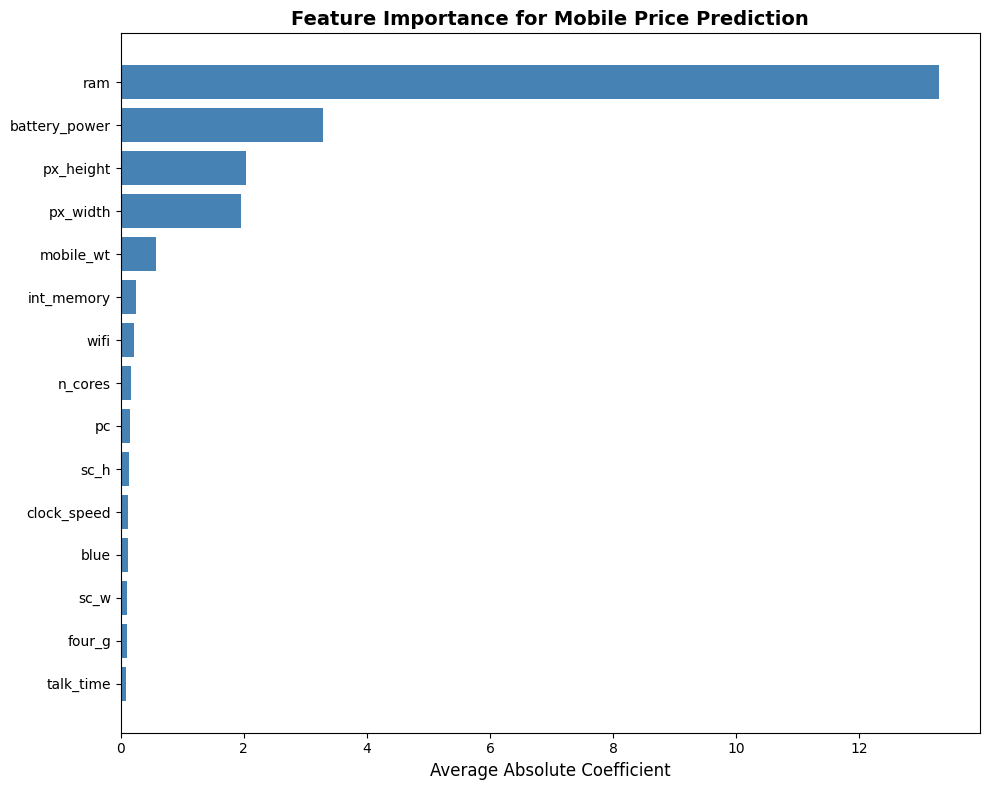


CLASS-SPECIFIC FEATURE INFLUENCE

Low Cost - Top 5 Positive Influencers:
  • mobile_wt: 0.8875
  • wifi: 0.4844
  • three_g: 0.2486
  • talk_time: 0.2331
  • sc_h: 0.2269
Low Cost - Top 5 Negative Influencers:
  • ram: -26.7622
  • battery_power: -6.5000
  • px_height: -4.2285
  • px_width: -3.7916
  • n_cores: -0.4285

Medium Cost - Top 5 Positive Influencers:
  • mobile_wt: 0.0859
  • wifi: 0.0540
  • four_g: 0.0391
  • blue: 0.0278
  • clock_speed: 0.0237
Medium Cost - Top 5 Negative Influencers:
  • ram: -2.2849
  • battery_power: -0.5514
  • px_width: -0.3547
  • px_height: -0.3404
  • pc: -0.0431

High Cost - Top 5 Positive Influencers:
  • mobile_wt: 0.0651
  • wifi: 0.0293
  • dual_sim: 0.0194
  • blue: 0.0186
  • sc_w: 0.0087
High Cost - Top 5 Negative Influencers:
  • ram: -1.1602
  • battery_power: -0.2942
  • px_height: -0.1936
  • px_width: -0.1553
  • sc_h: -0.0170

Very High Cost - Top 5 Positive Influencers:
  • mobile_wt: 0.8849
  • wifi: 0.4846
  • four_g: 0.2897
  •

In [5]:
# Extract coefficients from the best model
coefficients = best_model.coef_
feature_names = X.columns

# For multi-class, get average absolute importance across all classes
importance = np.abs(coefficients).mean(axis=0)

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("TOP 15 FEATURES INFLUENCING MOBILE PRICE")
print("="*60)

for idx, row in importance_df.head(15).iterrows():
    print(f"{idx+1:2d}. {row['Feature']:20s}: {row['Importance']:.6f}")

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][:15], importance_df['Importance'][:15], color='steelblue')
plt.xlabel('Average Absolute Coefficient', fontsize=12)
plt.title('Feature Importance for Mobile Price Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Also show which features have high coefficients for specific classes
print("\n" + "="*60)
print("CLASS-SPECIFIC FEATURE INFLUENCE")
print("="*60)

for class_idx, class_name in enumerate(['Low', 'Medium', 'High', 'Very High']):
    top_features = np.argsort(coefficients[class_idx])[-5:][::-1]
    print(f"\n{class_name} Cost - Top 5 Positive Influencers:")
    for feat_idx in top_features:
        print(f"  • {feature_names[feat_idx]}: {coefficients[class_idx][feat_idx]:.4f}")

    bottom_features = np.argsort(coefficients[class_idx])[:5]
    print(f"{class_name} Cost - Top 5 Negative Influencers:")
    for feat_idx in bottom_features:
        print(f"  • {feature_names[feat_idx]}: {coefficients[class_idx][feat_idx]:.4f}")

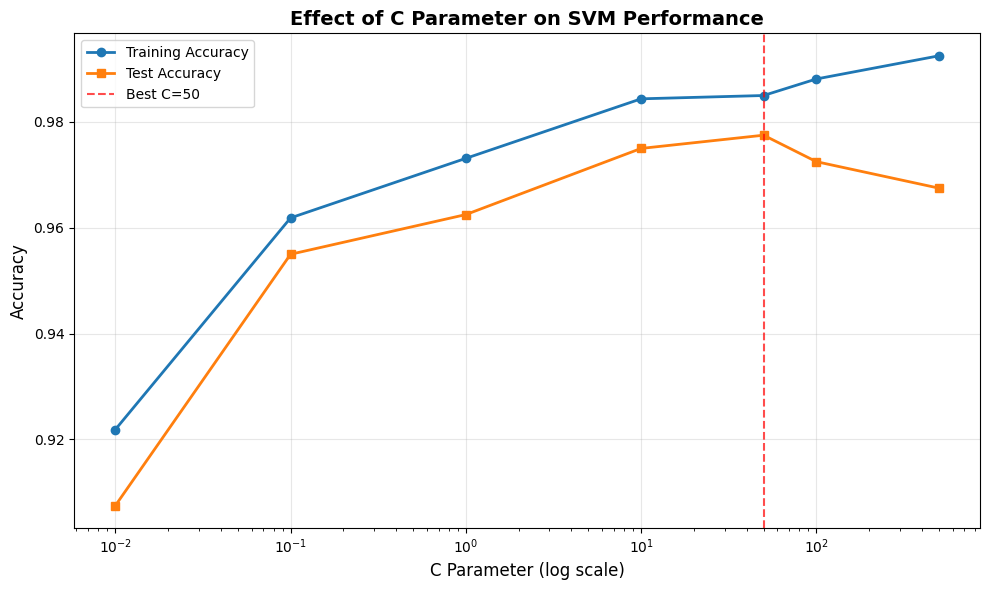


C Parameter Analysis:
• C=50 (Best): 97.75% test accuracy
• C=1 (Simple): 96.25% test accuracy
• Improvement: +1.50%


In [6]:
# Visualize how C parameter affects accuracy
C_values = [0.01, 0.1, 1, 10, 50, 100, 500]
train_scores = []
test_scores = []

for C in C_values:
    svm = SVC(kernel='linear', C=C, random_state=42)
    svm.fit(X_train_scaled, y_train)
    train_scores.append(svm.score(X_train_scaled, y_train))
    test_scores.append(svm.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.semilogx(C_values, train_scores, 'o-', label='Training Accuracy', linewidth=2)
plt.semilogx(C_values, test_scores, 's-', label='Test Accuracy', linewidth=2)
plt.xlabel('C Parameter (log scale)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Effect of C Parameter on SVM Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Best C=50')
plt.legend()
plt.tight_layout()
plt.show()

print("\nC Parameter Analysis:")
print(f"• C=50 (Best): {test_scores[C_values.index(50)]*100:.2f}% test accuracy")
print(f"• C=1 (Simple): {test_scores[C_values.index(1)]*100:.2f}% test accuracy")
print(f"• Improvement: +{(test_scores[C_values.index(50)] - test_scores[C_values.index(1)])*100:.2f}%")

In [7]:
import joblib
from datetime import datetime

# Save models with versioning
model_info = {
    'model': best_model,
    'scaler': scaler,
    'accuracy': test_accuracy,
    'cv_score': 0.9606,
    'C_value': 50,
    'kernel': 'linear',
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'features': list(X.columns),
    'n_samples': len(X),
    'n_features': X.shape[1]
}

# Save complete pipeline
joblib.dump(model_info, 'mobile_price_model_v1.pkl')
print("\n✅ Model saved as 'mobile_price_model_v1.pkl'")

# Also save individual components for easy deployment
joblib.dump(best_model, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print("✅ Individual components saved for deployment")


✅ Model saved as 'mobile_price_model_v1.pkl'
✅ Individual components saved for deployment


In [8]:
def predict_mobile_price(features_dict, model=best_model, scaler=scaler, feature_names=X.columns):
    """
    Predict price range for a mobile phone

    Parameters:
    features_dict: dict with feature names as keys
    """
    # Convert dict to array in correct order
    features_array = np.array([features_dict[feat] for feat in feature_names]).reshape(1, -1)

    # Scale features
    features_scaled = scaler.transform(features_array)

    # Predict
    prediction = model.predict(features_scaled)[0]

    # Get decision function values (confidence)
    decision_values = model.decision_function(features_scaled)[0]

    price_ranges = {0: "Low Cost (0)", 1: "Medium Cost (1)", 2: "High Cost (2)", 3: "Very High Cost (3)"}

    print("="*50)
    print("MOBILE PRICE PREDICTION")
    print("="*50)
    print(f"Predicted: {price_ranges[prediction]}")
    print(f"\nConfidence scores (decision function):")
    for i, score in enumerate(decision_values):
        print(f"  {price_ranges[i]}: {score:.2f}")

    return prediction, decision_values

# Example prediction
sample_phone = {
    'battery_power': 1500,
    'blue': 1,
    'clock_speed': 2.2,
    'dual_sim': 1,
    'fc': 8,
    'four_g': 1,
    'int_memory': 64,
    'm_dep': 0.5,
    'mobile_wt': 150,
    'n_cores': 4,
    'pc': 12,
    'px_height': 800,
    'px_width': 1200,
    'ram': 3000,
    'sc_h': 15,
    'sc_w': 8,
    'talk_time': 12,
    'three_g': 1,
    'touch_screen': 1,
    'wifi': 1
}

predict_mobile_price(sample_phone)

MOBILE PRICE PREDICTION
Predicted: Very High Cost (3)

Confidence scores (decision function):
  Low Cost (0): -0.33
  Medium Cost (1): 1.32
  High Cost (2): 2.32
  Very High Cost (3): 3.29


(np.int64(3), array([-0.32719784,  1.31958335,  2.31989199,  3.28759086]))